# OLS vs Hough on Synthetic 2D Point Sets

This notebook compares two ways to describe a line from scattered 2D data points.

## 1. Ordinary Least Squares (OLS)
OLS fits a line of the form $y = ax + b$ by minimizing the sum of squared **vertical** residuals:

$$
(\hat{a}, \hat{b}) = \arg\min_{a,b} \sum_{i=1}^{N} \left(y_i - (a x_i + b)\right)^2
$$

This is simple and efficient, but it is not orientation-invariant because the error is measured only in the $y$ direction. That is why near-vertical lines are a bad match for the model $y = ax + b$.

## 2. Hough line transform
The Hough transform uses the normal form of a line:

$$
\rho = x \cos\theta + y \sin\theta
$$

Instead of minimizing residuals directly, each point votes in $(\rho, \theta)$ space. Peaks in that voting space correspond to dominant lines. This makes Hough useful when we have multiple line families, clutter, or partial visibility.

Below, each scenario shows:
- black points: synthetic data
- blue line: OLS regression line
- orange/green line: dominant Hough line(s)

To keep the code short, the points are rasterized onto a small binary grid and `skimage.transform.hough_line` is used directly.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from skimage.transform import hough_line, hough_line_peaks

try:
    from numpy.exceptions import RankWarning
except ImportError:
    RankWarning = getattr(np, 'RankWarning', Warning)

GRID_SIZE = 101


def line_points(p0, p1, n=40, noise=0.0, seed=0, gaps=()):
    rng = np.random.default_rng(seed)
    t = np.linspace(0, 1, n)
    keep = np.ones_like(t, dtype=bool)
    for a, b in gaps:
        keep &= ~((t >= a) & (t <= b))
    t = t[keep]
    pts = np.column_stack([
        p0[0] + (p1[0] - p0[0]) * t,
        p0[1] + (p1[1] - p0[1]) * t,
    ])
    return pts + rng.normal(scale=noise, size=pts.shape)


def fit_ols(points):
    x, y = points[:, 0], points[:, 1]
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RankWarning)
        slope, intercept = np.polyfit(x, y, 1)
    unstable = (x.max() - x.min()) < 0.12 * max(y.max() - y.min(), 1.0) or abs(slope) > 8
    return {'slope': float(slope), 'intercept': float(intercept), 'unstable': bool(unstable)}


def point_image(points, size=GRID_SIZE):
    img = np.zeros((size, size), dtype=bool)
    xy = np.clip(np.rint(points).astype(int), 0, size - 1)
    img[size - 1 - xy[:, 1], xy[:, 0]] = True
    return img


def fit_hough(points, n_lines=1):
    h, theta, dist = hough_line(point_image(points))
    votes, angles, rhos = hough_line_peaks(
        h,
        theta,
        dist,
        num_peaks=n_lines,
        min_distance=8,
        min_angle=10,
    )
    return [{'votes': int(v), 'theta': float(a), 'rho': float(r)} for v, a, r in zip(votes, angles, rhos)]


def clip_line(A, B, C, xlim=(0, 100), ylim=(0, 100), eps=1e-9):
    xmin, xmax = xlim
    ymin, ymax = ylim
    candidates = []
    if abs(B) > eps:
        candidates += [(xmin, (C - A * xmin) / B), (xmax, (C - A * xmax) / B)]
    if abs(A) > eps:
        candidates += [((C - B * ymin) / A, ymin), ((C - B * ymax) / A, ymax)]
    inside = []
    for x, y in candidates:
        if xmin <= x <= xmax and ymin <= y <= ymax:
            if not any(abs(x - px) < 1e-6 and abs(y - py) < 1e-6 for px, py in inside):
                inside.append((x, y))
    return inside[:2] if len(inside) >= 2 else None


def plot_case(ax, title, subtitle, points, n_hough=1):
    ols = fit_ols(points)
    hough = fit_hough(points, n_lines=n_hough)

    ax.scatter(points[:, 0], points[:, 1], s=22, color='black', alpha=0.75)

    seg = clip_line(-ols['slope'], 1.0, ols['intercept'])
    if seg:
        (x0, y0), (x1, y1) = seg
        ax.plot([x0, x1], [y0, y1], color='tab:blue', lw=2.5, ls='--' if ols['unstable'] else '-')

    colors = ['tab:orange', 'tab:green']
    for i, line in enumerate(hough):
        A = np.cos(line['theta'])
        B = -np.sin(line['theta'])
        C = line['rho'] - (GRID_SIZE - 1) * np.sin(line['theta'])
        seg = clip_line(A, B, C)
        if seg:
            (x0, y0), (x1, y1) = seg
            ax.plot([x0, x1], [y0, y1], color=colors[i], lw=2.5)

    if ols['unstable']:
        ax.text(0.03, 0.05, 'OLS: y = ax + b is not a good model here', transform=ax.transAxes, fontsize=8, color='tab:blue')

    ax.set_title(f'{title}\n{subtitle}', fontsize=10)
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(alpha=0.2)


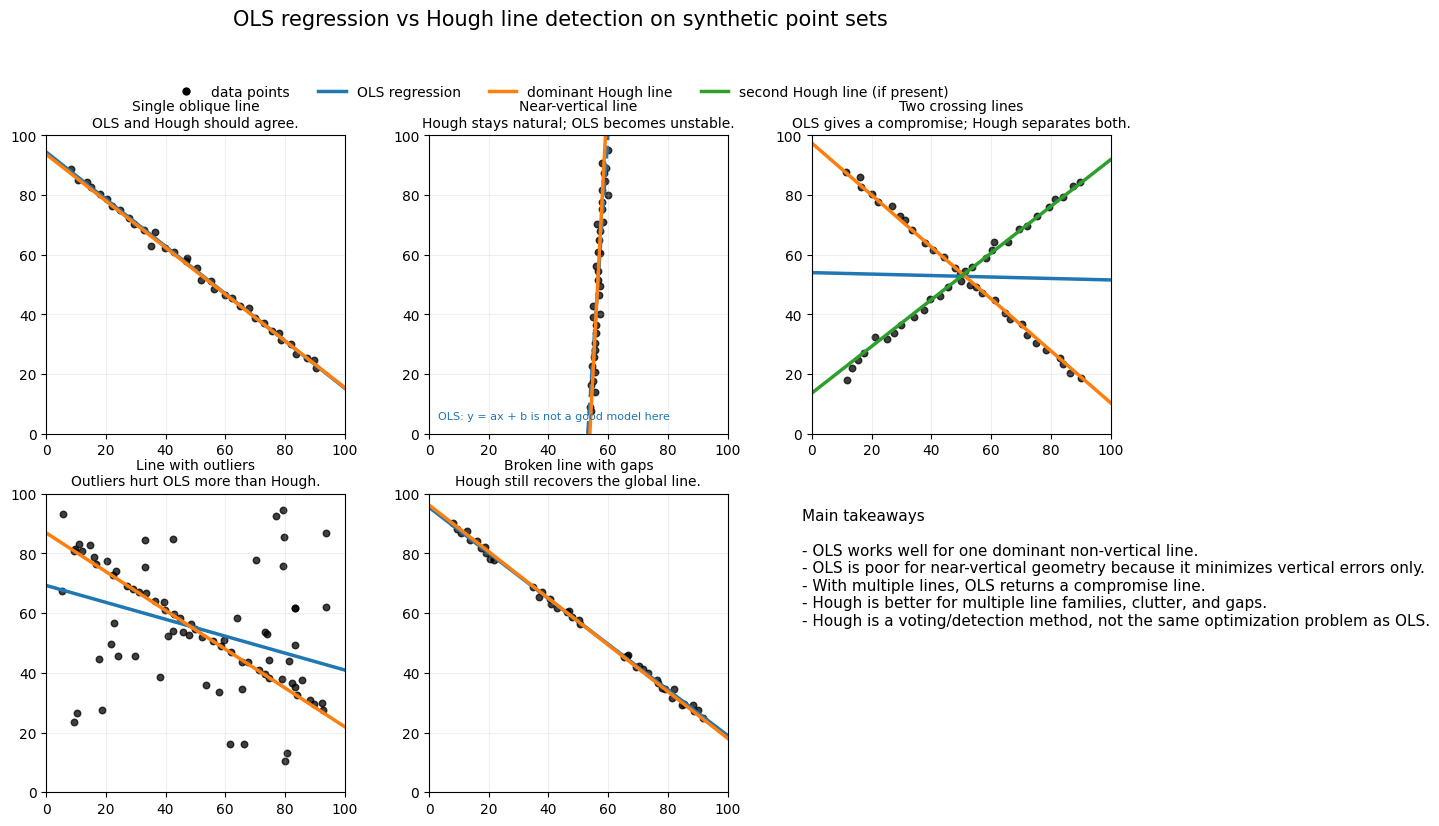

In [2]:
scenarios = [
    ('Single oblique line', 'OLS and Hough should agree.', line_points((8, 88), (92, 22), n=35, noise=0.9, seed=1), 1),
    ('Near-vertical line', 'Hough stays natural; OLS becomes unstable.', line_points((54, 8), (59, 95), n=35, noise=0.7, seed=2), 1),
    ('Two crossing lines', 'OLS gives a compromise; Hough separates both.', np.vstack([
        line_points((10, 20), (90, 85), n=28, noise=0.8, seed=3),
        line_points((12, 88), (90, 18), n=28, noise=0.8, seed=4),
    ]), 2),
    ('Line with outliers', 'Outliers hurt OLS more than Hough.', np.vstack([
        line_points((10, 82), (92, 28), n=35, noise=1.0, seed=5),
        np.random.default_rng(6).uniform(5, 95, size=(45, 2)),
    ]), 1),
    ('Broken line with gaps', 'Hough still recovers the global line.', line_points((8, 90), (92, 25), n=55, noise=0.9, seed=7, gaps=((0.20, 0.32), (0.52, 0.66))), 1),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))

for ax, (title, subtitle, pts, n_hough) in zip(axes.flat, scenarios):
    plot_case(ax, title, subtitle, pts, n_hough=n_hough)

summary = (
    'Main takeaways\n\n'
    '- OLS works well for one dominant non-vertical line.\n'
    '- OLS is poor for near-vertical geometry because it minimizes vertical errors only.\n'
    '- With multiple lines, OLS returns a compromise line.\n'
    '- Hough is better for multiple line families, clutter, and gaps.\n'
    '- Hough is a voting/detection method, not the same optimization problem as OLS.'
)

axes.flat[-1].axis('off')
axes.flat[-1].text(0.0, 0.95, summary, va='top', fontsize=11)

legend = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markersize=7, label='data points'),
    Line2D([0], [0], color='tab:blue', lw=2.5, label='OLS regression'),
    Line2D([0], [0], color='tab:orange', lw=2.5, label='dominant Hough line'),
    Line2D([0], [0], color='tab:green', lw=2.5, label='second Hough line (if present)'),
]
fig.subplots_adjust(top=0.84)
fig.legend(handles=legend, loc='upper center', bbox_to_anchor=(0.5, 0.91), ncol=4, frameon=False)
fig.suptitle('OLS regression vs Hough line detection on synthetic point sets', fontsize=15, y=0.98)
plt.show()


In [3]:
# Near-vertical points helper: configurable N, x stays very close, y spans a large range.
def near_vertical_points(N, x_center=54.0, x_jitter=1.0, y_min=8.0, y_max=95.0, seed=42):
    rng = np.random.default_rng(seed)
    y = np.linspace(y_min, y_max, N)
    x = x_center + rng.uniform(-x_jitter, x_jitter, size=N)
    return np.column_stack([x, y]).astype(np.float32)



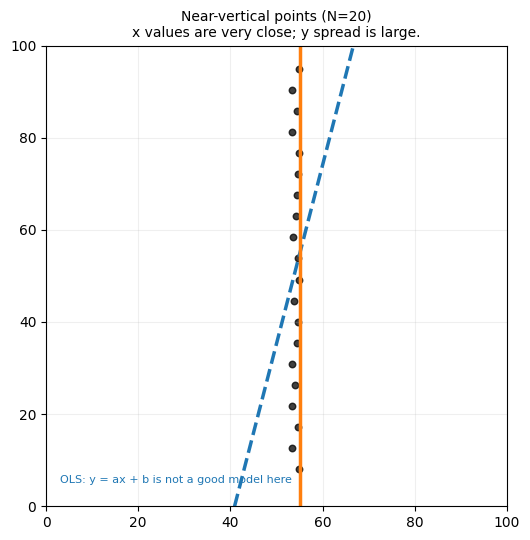

In [8]:
# Extra case 1: N = 2 near-vertical points
N = 20
pts_two = near_vertical_points(N, x_center=54.0, x_jitter=1.0, y_min=8.0, y_max=95.0, seed=10)

fig, ax = plt.subplots(1, 1, figsize=(5.5, 5.5))
plot_case(
    ax,
    f'Near-vertical points (N={N})',
    'x values are very close; y spread is large.',
    pts_two,
    n_hough=1,
)
plt.tight_layout()
plt.show()


# Best Geometric Line Fitting Equals PCA in 2D

This notebook shows that the **best-fit line in the geometric least-squares sense** is the same as the **PCA line** in 2D.

## 1. Geometric line fitting

For points $p_i \in \mathbb{R}^2$, the geometric objective is to minimize the sum of squared **perpendicular** distances to a line $L$:

$$
\min_L \sum_{i=1}^N d(p_i, L)^2.
$$

Write the line in parametric form as

$$
L = \{\mu + t v : t \in \mathbb{R},\ \|v\| = 1\},
$$

where $\mu$ is a point on the line and $v$ is the line direction. If we center the data at the centroid

$$
\mu = \frac{1}{N} \sum_{i=1}^N p_i,
\qquad
q_i = p_i - \mu,
$$

then the squared perpendicular distance from $p_i$ to the line is

$$
\|q_i\|^2 - (v^\top q_i)^2.
$$

So the total error becomes

$$
\sum_{i=1}^N d(p_i, L)^2
= \sum_{i=1}^N \|q_i\|^2 - \sum_{i=1}^N (v^\top q_i)^2.
$$

The first term is constant, so minimizing perpendicular error is equivalent to maximizing variance along the line direction:

$$
\max_{\|v\|=1} \sum_{i=1}^N (v^\top q_i)^2
= \max_{\|v\|=1} v^\top \Sigma v,
$$

where

$$
\Sigma = \frac{1}{N} \sum_{i=1}^N q_i q_i^\top
$$

is the covariance matrix.

## 2. Why PCA appears

By the Rayleigh-Ritz principle,

$$
\max_{\|v\|=1} v^\top \Sigma v = \lambda_{\max},
\qquad
\min_{\|n\|=1} n^\top \Sigma n = \lambda_{\min}.
$$

Therefore:

- the **best-fit line direction** is the eigenvector $v_1$ of the largest eigenvalue
- the **line normal** is the eigenvector $v_2$ of the smallest eigenvalue
- the line passes through the centroid $\mu$

So the geometric best-fit line is

$$
x = \mu + t v_1,
$$

or equivalently in normal form,

$$
v_2^\top x = v_2^\top \mu.
$$

## 3. Difference from OLS regression

Ordinary least squares fits

$$
y = ax + b
$$

by minimizing **vertical** residuals:

$$
\min_{a,b} \sum_{i=1}^N \left(y_i - (a x_i + b)\right)^2.
$$

That is a different optimization problem. OLS is prediction-oriented, while PCA / orthogonal line fitting is geometry-oriented.

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

OUTPUT_DIR = Path('outputs/pca_linefit')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def sample_gaussian(mean, angle_deg, scales, n=160, seed=0):
    rng = np.random.default_rng(seed)
    theta = np.deg2rad(angle_deg)
    R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
    D = np.diag(np.asarray(scales, dtype=float) ** 2)
    cov = R @ D @ R.T
    return rng.multivariate_normal(mean, cov, size=n)


def generate_case_oblique():
    return sample_gaussian(mean=(0.0, 0.0), angle_deg=35, scales=(3.5, 0.45), n=170, seed=1)


def generate_case_vertical():
    return sample_gaussian(mean=(1.0, 0.0), angle_deg=87, scales=(4.0, 0.35), n=170, seed=2)


def generate_case_horizontal():
    return sample_gaussian(mean=(0.0, 1.0), angle_deg=2, scales=(3.8, 0.7), n=170, seed=3)


def generate_case_isotropic():
    return sample_gaussian(mean=(0.0, 0.0), angle_deg=0, scales=(2.2, 2.0), n=170, seed=4)


def generate_case_outliers():
    base = sample_gaussian(mean=(0.0, 0.0), angle_deg=28, scales=(3.2, 0.45), n=150, seed=5)
    outliers = np.array([[7.0, -5.5], [6.5, -6.2], [-6.8, 5.8], [-7.5, 6.4], [8.0, -4.7]])
    return np.vstack([base, outliers])


def fit_pca_line(points):
    centroid = points.mean(axis=0)
    centered = points - centroid
    cov = centered.T @ centered / len(points)
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]
    direction = eigenvectors[:, 0]
    normal = eigenvectors[:, 1]
    if direction[0] < 0:
        direction = -direction
        normal = -normal
    explained = eigenvalues / eigenvalues.sum()
    return {
        'centroid': centroid,
        'covariance': cov,
        'eigenvalues': eigenvalues,
        'eigenvectors': np.column_stack([direction, normal]),
        'direction': direction,
        'normal': normal,
        'explained_ratio': explained,
    }


def fit_ols_line(points):
    x, y = points[:, 0], points[:, 1]
    slope, intercept = np.polyfit(x, y, 1)
    unstable = np.std(x) < 0.25 * np.std(y) or abs(slope) > 8
    return {'slope': float(slope), 'intercept': float(intercept), 'unstable': bool(unstable)}


def project_to_line(points, point, direction):
    unit_dir = direction / np.linalg.norm(direction)
    t = (points - point) @ unit_dir
    return point + np.outer(t, unit_dir)


def draw_line_from_point_direction(ax, point, direction, span, **kwargs):
    unit_dir = direction / np.linalg.norm(direction)
    ends = np.vstack([point - span * unit_dir, point + span * unit_dir])
    ax.plot(ends[:, 0], ends[:, 1], **kwargs)


def pca_line_equation(result):
    c = result['centroid']
    d = result['direction']
    n = result['normal']
    rho = n @ c
    return (
        f'x = ({c[0]:.2f}, {c[1]:.2f}) + t ({d[0]:.3f}, {d[1]:.3f})',
        f'{n[0]:.3f} x + {n[1]:.3f} y = {rho:.3f}'
    )


def make_case_figure(points, case_name, lesson, filename, draw_projections=False):
    pca = fit_pca_line(points)
    ols = fit_ols_line(points)
    centroid = pca['centroid']
    direction = pca['direction']
    normal = pca['normal']

    mins = points.min(axis=0)
    maxs = points.max(axis=0)
    center = 0.5 * (mins + maxs)
    half = 0.65 * np.max(maxs - mins)
    xlim = (center[0] - half, center[0] + half)
    ylim = (center[1] - half, center[1] + half)

    fig, ax = plt.subplots(figsize=(6.6, 6.2))
    ax.scatter(points[:, 0], points[:, 1], s=18, alpha=0.7, color='black', label='points')
    ax.scatter(*centroid, s=110, color='crimson', marker='X', label='centroid', zorder=4)

    draw_line_from_point_direction(ax, centroid, direction, span=half * 1.25, color='tab:blue', lw=2.6, label='PCA / geometric best-fit line')

    xs = np.linspace(*xlim, 200)
    ax.plot(xs, ols['slope'] * xs + ols['intercept'], '--', color='tab:orange', lw=2.1, label='OLS line')

    scale = half * 0.42
    ax.arrow(*centroid, *(scale * direction), width=0.02 * half, color='tab:blue', alpha=0.85, length_includes_head=True)
    ax.arrow(*centroid, *(scale * normal), width=0.02 * half, color='tab:green', alpha=0.85, length_includes_head=True)
    ax.text(*(centroid + scale * direction * 1.08), 'PC1', color='tab:blue', fontsize=10)
    ax.text(*(centroid + scale * normal * 1.08), 'PC2', color='tab:green', fontsize=10)

    if draw_projections:
        sample_idx = np.linspace(0, len(points) - 1, 7, dtype=int)
        projections = project_to_line(points[sample_idx], centroid, direction)
        for p, q in zip(points[sample_idx], projections):
            ax.plot([p[0], q[0]], [p[1], q[1]], color='0.65', lw=1.1, alpha=0.9)

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(alpha=0.25)
    ax.legend(loc='upper left', fontsize=9)
    ax.set_title(f'{case_name}\n{lesson}', fontsize=11)
    ax.set_xlabel('x')
    ax.set_ylabel('y')

    fig.savefig(OUTPUT_DIR / filename, dpi=160, bbox_inches='tight')
    plt.show()

    parametric, normal_form = pca_line_equation(pca)
    print(f'--- {case_name} ---')
    print('Centroid:', np.array2string(centroid, precision=3))
    print('Covariance matrix:\n', np.array2string(pca['covariance'], precision=3))
    print('Eigenvalues:', np.array2string(pca['eigenvalues'], precision=3))
    print('Explained variance ratio:', np.array2string(pca['explained_ratio'], precision=3))
    print('PCA line (parametric):', parametric)
    print('PCA line (normal):   ', normal_form)
    print(f"OLS line: y = {ols['slope']:.3f} x + {ols['intercept']:.3f}")
    if ols['unstable']:
        print('OLS note: steep / orientation-sensitive case, so y = ax + b is not the natural geometric model.')
    print()


def run_all_cases():
    cases = [
        ('Case 1 - Oblique cloud', 'PC1 aligns with the elongated cloud; PCA and geometric line fitting coincide.', generate_case_oblique(), 'case_01_oblique.png', True),
        ('Case 2 - Near-vertical cloud', 'PCA gives a near-vertical geometric line, while OLS becomes awkward.', generate_case_vertical(), 'case_02_vertical.png', True),
        ('Case 3 - Horizontal cloud', 'Both PCA and OLS are reasonable in this easy sanity-check case.', generate_case_horizontal(), 'case_03_horizontal.png', False),
        ('Case 4 - Nearly isotropic cloud', 'PCA still returns a direction, but the two eigenvalues are close, so the line is weak.', generate_case_isotropic(), 'case_04_isotropic.png', False),
        ('Case 5 - Outliers', 'Both PCA and OLS move under outliers; neither method is robust.', generate_case_outliers(), 'case_05_outliers.png', True),
    ]
    for case_name, lesson, points, filename, draw_proj in cases:
        make_case_figure(points, case_name, lesson, filename, draw_projections=draw_proj)
    print('Conclusion: In 2D, the best line in the geometric least-squares sense is the PCA line: it passes through the centroid and follows the first principal component. Ordinary linear regression is different because it minimizes vertical prediction errors rather than perpendicular geometric distances.')


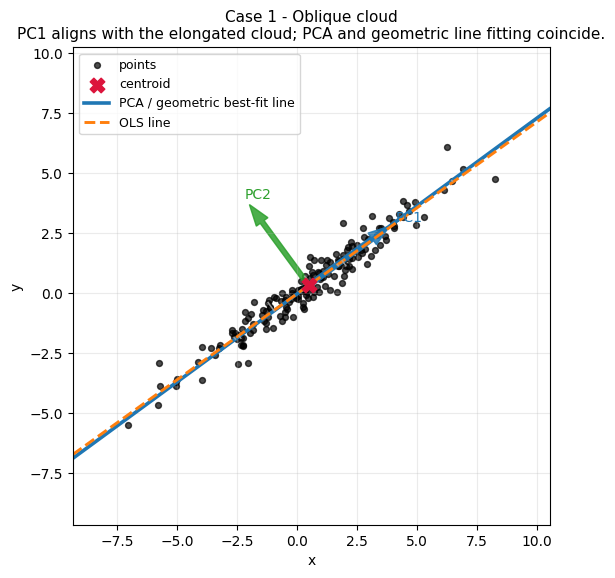

--- Case 1 - Oblique cloud ---
Centroid: [0.491 0.32 ]
Covariance matrix:
 [[7.003 5.018]
 [5.018 3.835]]
Eigenvalues: [10.681  0.156]
Explained variance ratio: [0.986 0.014]
PCA line (parametric): x = (0.49, 0.32) + t (0.807, 0.591)
PCA line (normal):    -0.591 x + 0.807 y = -0.032
OLS line: y = 0.717 x + -0.031



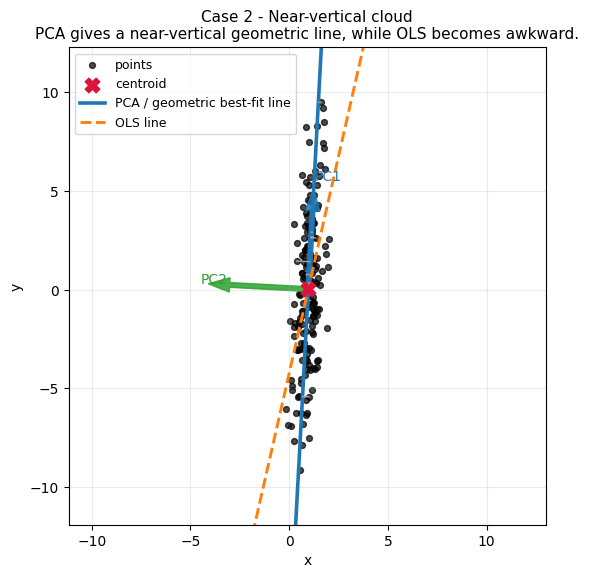

--- Case 2 - Near-vertical cloud ---
Centroid: [0.966 0.024]
Covariance matrix:
 [[ 0.179  0.785]
 [ 0.785 14.721]]
Eigenvalues: [14.763  0.136]
Explained variance ratio: [0.991 0.009]
PCA line (parametric): x = (0.97, 0.02) + t (0.054, 0.999)
PCA line (normal):    -0.999 x + 0.054 y = -0.964
OLS line: y = 4.397 x + -4.225
OLS note: steep / orientation-sensitive case, so y = ax + b is not the natural geometric model.



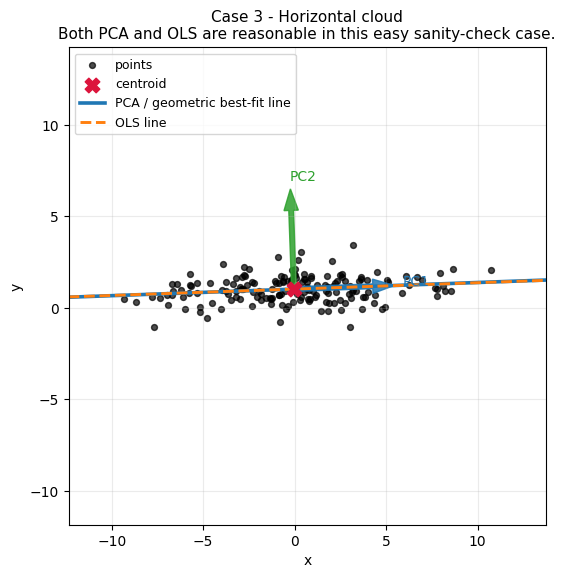

--- Case 3 - Horizontal cloud ---
Centroid: [-0.039  1.022]
Covariance matrix:
 [[15.401  0.536]
 [ 0.536  0.517]]
Eigenvalues: [15.42   0.497]
Explained variance ratio: [0.969 0.031]
PCA line (parametric): x = (-0.04, 1.02) + t (0.999, 0.036)
PCA line (normal):    -0.036 x + 0.999 y = 1.023
OLS line: y = 0.035 x + 1.023



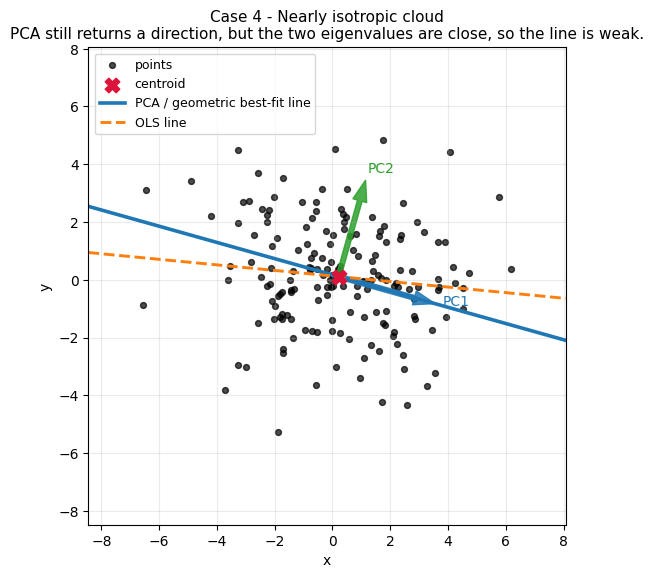

--- Case 4 - Nearly isotropic cloud ---
Centroid: [0.209 0.112]
Covariance matrix:
 [[ 5.182 -0.498]
 [-0.498  3.548]]
Eigenvalues: [5.322 3.408]
Explained variance ratio: [0.61 0.39]
PCA line (parametric): x = (0.21, 0.11) + t (0.963, -0.270)
PCA line (normal):    0.270 x + 0.963 y = 0.165
OLS line: y = -0.096 x + 0.132



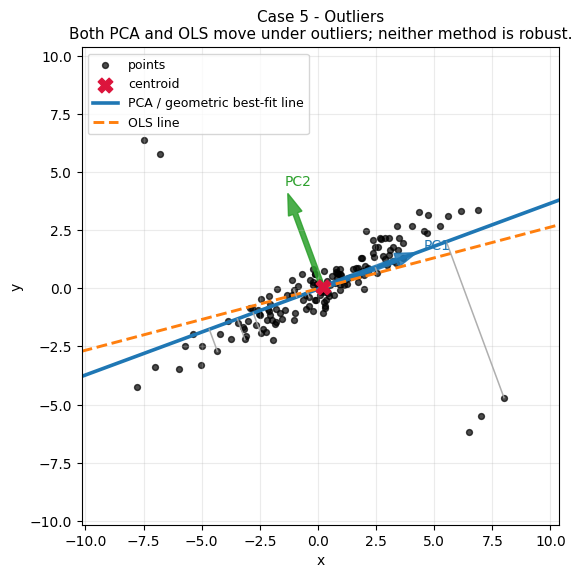

--- Case 5 - Outliers ---
Centroid: [0.195 0.038]
Covariance matrix:
 [[8.33  2.207]
 [2.207 3.168]]
Eigenvalues: [9.145 2.353]
Explained variance ratio: [0.795 0.205]
PCA line (parametric): x = (0.20, 0.04) + t (0.938, 0.346)
PCA line (normal):    -0.346 x + 0.938 y = -0.032
OLS line: y = 0.265 x + -0.014

Conclusion: In 2D, the best line in the geometric least-squares sense is the PCA line: it passes through the centroid and follows the first principal component. Ordinary linear regression is different because it minimizes vertical prediction errors rather than perpendicular geometric distances.


In [7]:
run_all_cases()